In [44]:
import math
import numpy
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [45]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    # LR: left to right
    # TB: top to bottom

    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for the value.
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [46]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), "*")


a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
print(a + b)
print(a * b)

d = a * b
d.label = "d"

e = d + c
e.label = "e"
print(e)
print(e._prev)
print(e._op)

f = Value(-2.0, label="f")

L = e * f
L.label = "L"

Value(data=-1.0)
Value(data=-6.0)
Value(data=4.0)
{Value(data=-6.0), Value(data=10.0)}
+


In [47]:
L.grad = 1.0
f.grad = 4.0
e.grad = -2.0
d.grad = -2.0
c.grad = -2.0
b.grad = -4.0
a.grad = 6.0

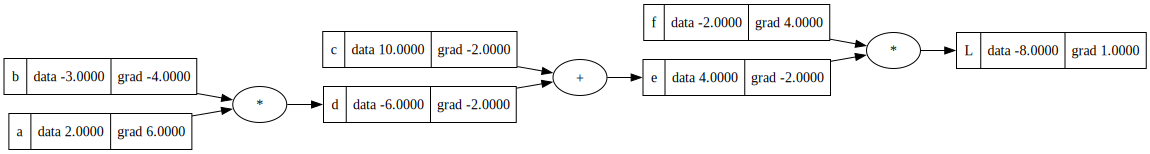

In [48]:
draw_dot(L)

In [49]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

In [50]:
d = a * b
d.label = "d"
e = d + c
e.label = "e"
L = e * f
L.label = "L"

print(f"{L.data:.30f}")

-7.286495999999999639840098097920


In [51]:
L.grad = 1.0000
f.grad = 3.7176
e.grad = -1.9600
d.grad = -1.9600
c.grad = -1.9600
b.grad = 2.0600 * -1.9600
a.grad = -3.0400 * -1.9600

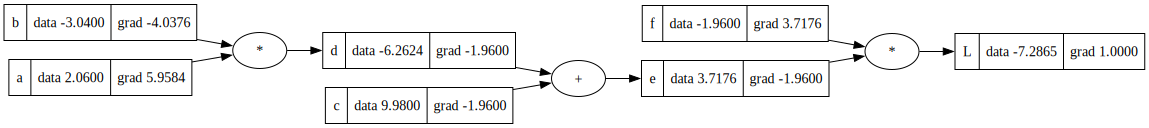

In [52]:
draw_dot(L)